In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.simplefilter("ignore")

# Load the dataset
df = pd.read_csv("vegemite.csv")

# Remove constant columns
df = df.loc[:, (df != df.iloc[0]).any()]

# Convert columns with few unique numerical values to categorical
few_unique = [col for col in df.columns if df[col].nunique() < 10 and df[col].dtype in ['int64', 'float64']]
for col in few_unique:
    df[col] = df[col].astype('category')

# Check class balance and print results.
class_counts = df['Class'].value_counts()
print("Class distribution:\n", class_counts)

# Print the number of features before further processing.
print("Number of initial features:", df.shape[1])


Class distribution:
 Class
2    7548
1    5047
0    2642
Name: count, dtype: int64
Number of initial features: 45


In [3]:
test_df = df.groupby('Class', group_keys=False).apply(lambda x: x.sample(n=333, random_state=1)).reset_index(drop=True)
train_df = df.drop(test_df.index).reset_index(drop=True)

In [4]:
import warnings
warnings.simplefilter("ignore")

In [5]:
df.head()

,FFTE Feed tank level SP,FFTE Production solids SP,FFTE Steam pressure SP,TFE Out flow SP,TFE Production solids SP,TFE Vacuum pressure SP,TFE Steam pressure SP,FFTE Feed flow SP,FFTE Out steam temp SP,Extract tank Level,...,TFE Motor speed,TFE Out flow PV,TFE Production solids PV,TFE Production solids density,TFE Steam pressure PV,TFE Steam temperature,TFE Tank level,TFE Temperature,TFE Vacuum pressure PV,Class
0,50.0,40.74,125.0,2897.65,69.0,-80.00,125.0,10130.0,49.88,66.41,...,80.0,2577.82,62.87,1.19,125.03,72.68,83.68,71.0,-77.74,1
1,50.0,40.74,125.0,2897.65,69.0,-79.45,125.0,10130.0,49.88,62.69,...,80.0,1551.88,67.98,1.19,125.03,64.66,82.95,69.0,-79.49,1
2,50.0,40.74,125.0,2897.65,69.0,-71.54,125.0,10130.0,49.88,65.05,...,80.0,1564.85,70.38,1.19,124.71,65.63,82.77,72.0,-75.28,1
3,50.0,40.74,125.0,2897.65,69.0,-68.44,125.0,10130.0,49.88,61.93,...,80.0,1512.97,69.18,1.19,124.71,74.35,82.55,76.0,-69.65,1
4,50.0,39.00,90.0,2694.62,64.0,-80.00,120.0,9300.0,49.88,67.39,...,80.0,1795.72,41.14,0.90,119.91,70.82,83.96,71.0,-75.28,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15237 entries, 0 to 15236
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   FFTE Feed tank level SP        15237 non-null  category
 1   FFTE Production solids SP      15237 non-null  float64 
 2   FFTE Steam pressure SP         15237 non-null  float64 
 3   TFE Out flow SP                15237 non-null  float64 
 4   TFE Production solids SP       15237 non-null  float64 
 5   TFE Vacuum pressure SP         15237 non-null  float64 
 6   TFE Steam pressure SP          15237 non-null  float64 
 7   FFTE Feed flow SP              15237 non-null  float64 
 8   FFTE Out steam temp SP         15237 non-null  float64 
 9   Extract tank Level             15237 non-null  float64 
 10  Extract tank Out flow PV       15237 non-null  float64 
 11  FFTE Discharge density         15237 non-null  float64 
 12  FFTE Discharge solids          1

        FFTE Feed tank level SP  FFTE Production solids SP  \
count                   15237.0               15237.000000   
unique                      3.0                        NaN   
top                        50.0                        NaN   
freq                    13201.0                        NaN   
mean                        NaN                  41.834045   
std                         NaN                   1.142426   
min                         NaN                  39.000000   
25%                         NaN                  41.110000   
50%                         NaN                  42.000000   
75%                         NaN                  43.000000   
max                         NaN                  43.000000   

        FFTE Steam pressure SP  TFE Out flow SP  TFE Production solids SP  \
count             15237.000000     15237.000000              15237.000000   
unique                     NaN              NaN                       NaN   
top                     

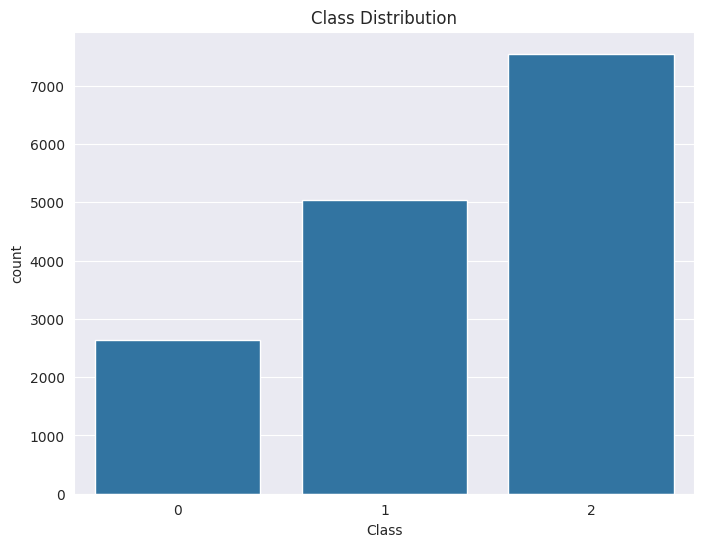

In [7]:
print(df.describe(include='all'))

# Plot class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()


In [8]:
# composite feature: ratio between two process variables
if 'Feed Flow PV' in df.columns and 'Feed Temp PV' in df.columns:
    df['Flow_Temp_Ratio'] = df['Feed Flow PV'] / (df['Feed Temp PV'] + 1e-5)  # avoid division by zero

# composite feature: deviation between SP and PV columns
sp_cols = [col for col in df.columns if col.endswith("SP")]
for sp in sp_cols:
    pv = sp.replace('SP', 'PV')
    if pv in df.columns:
        df[f'{sp}_deviation'] = df[sp].astype(float) - df[pv].astype(float)

# Print composite features added and updated feature count.
new_features = [col for col in df.columns if "Ratio" in col or "deviation" in col]
print("Composite features added:", new_features)
print("Total features after feature engineering:", df.shape[1])


Composite features added: ['FFTE Feed tank level SP_deviation', 'FFTE Production solids SP_deviation', 'FFTE Steam pressure SP_deviation', 'TFE Out flow SP_deviation', 'TFE Production solids SP_deviation', 'TFE Vacuum pressure SP_deviation', 'TFE Steam pressure SP_deviation', 'FFTE Out steam temp SP_deviation']
Total features after feature engineering: 53


        FFTE Feed tank level SP  FFTE Production solids SP  \
count                   14238.0               14238.000000   
unique                      3.0                        NaN   
top                        50.0                        NaN   
freq                    12510.0                        NaN   
mean                        NaN                  41.858399   
std                         NaN                   1.138743   
min                         NaN                  39.000000   
25%                         NaN                  41.500000   
50%                         NaN                  42.000000   
75%                         NaN                  43.000000   
max                         NaN                  43.000000   

        FFTE Steam pressure SP  TFE Out flow SP  TFE Production solids SP  \
count             14238.000000     14238.000000              14238.000000   
unique                     NaN              NaN                       NaN   
top                     

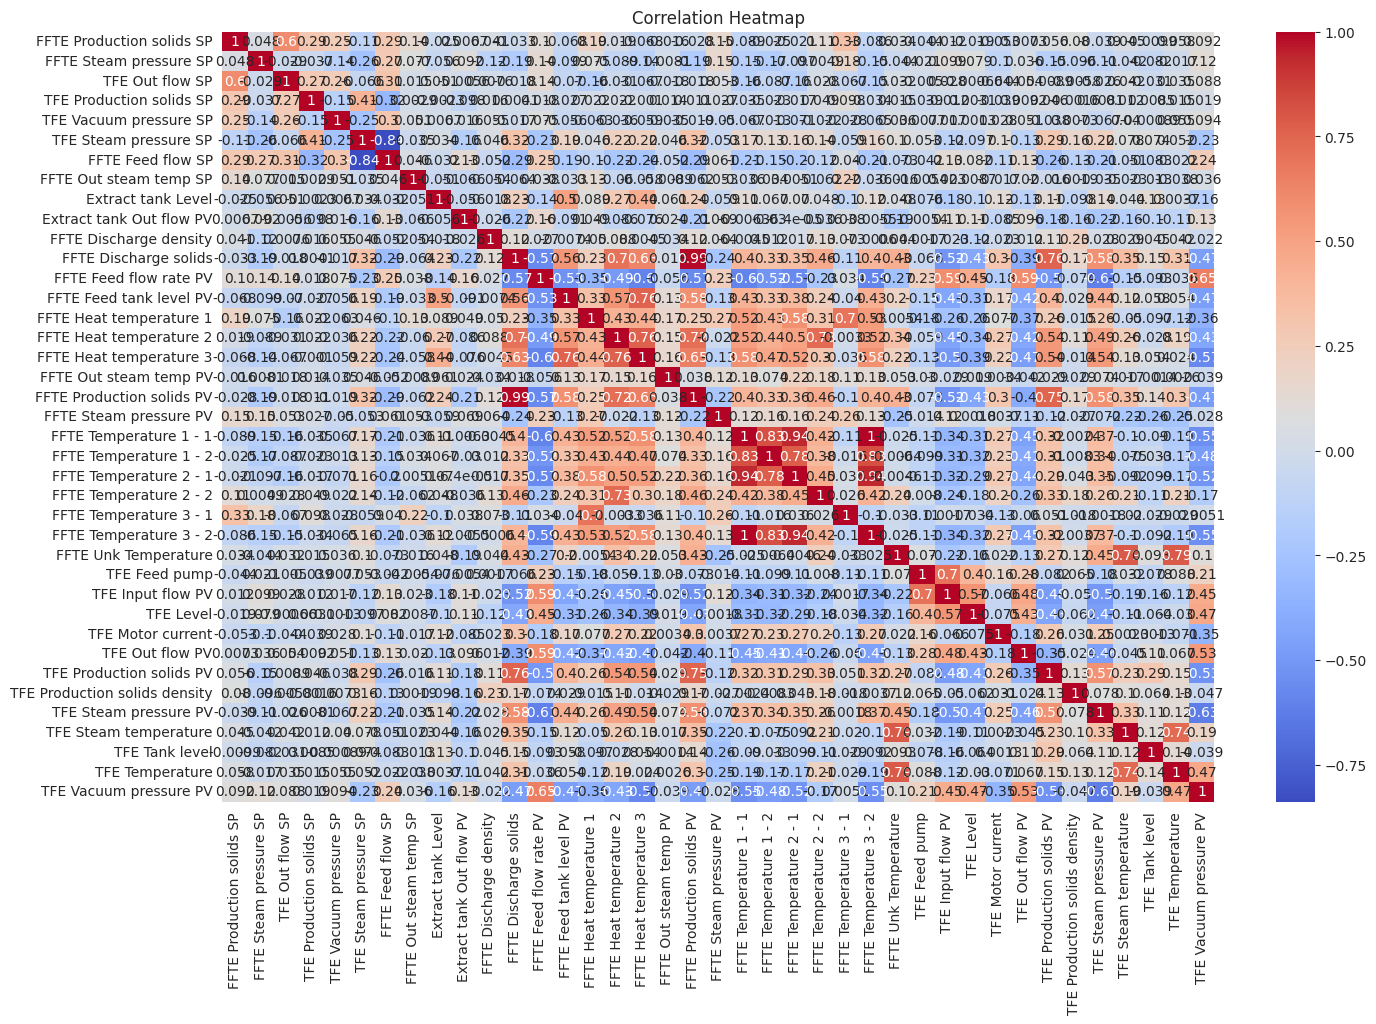

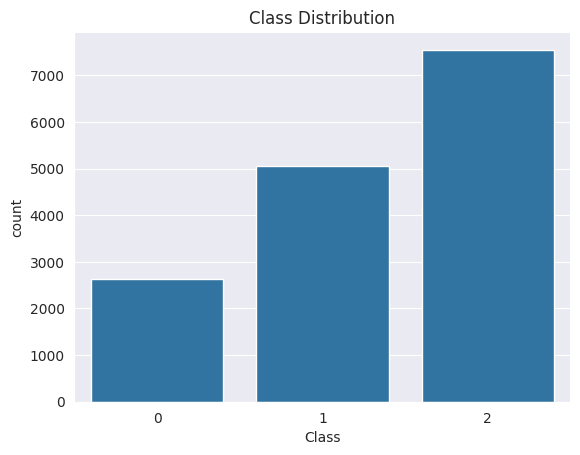

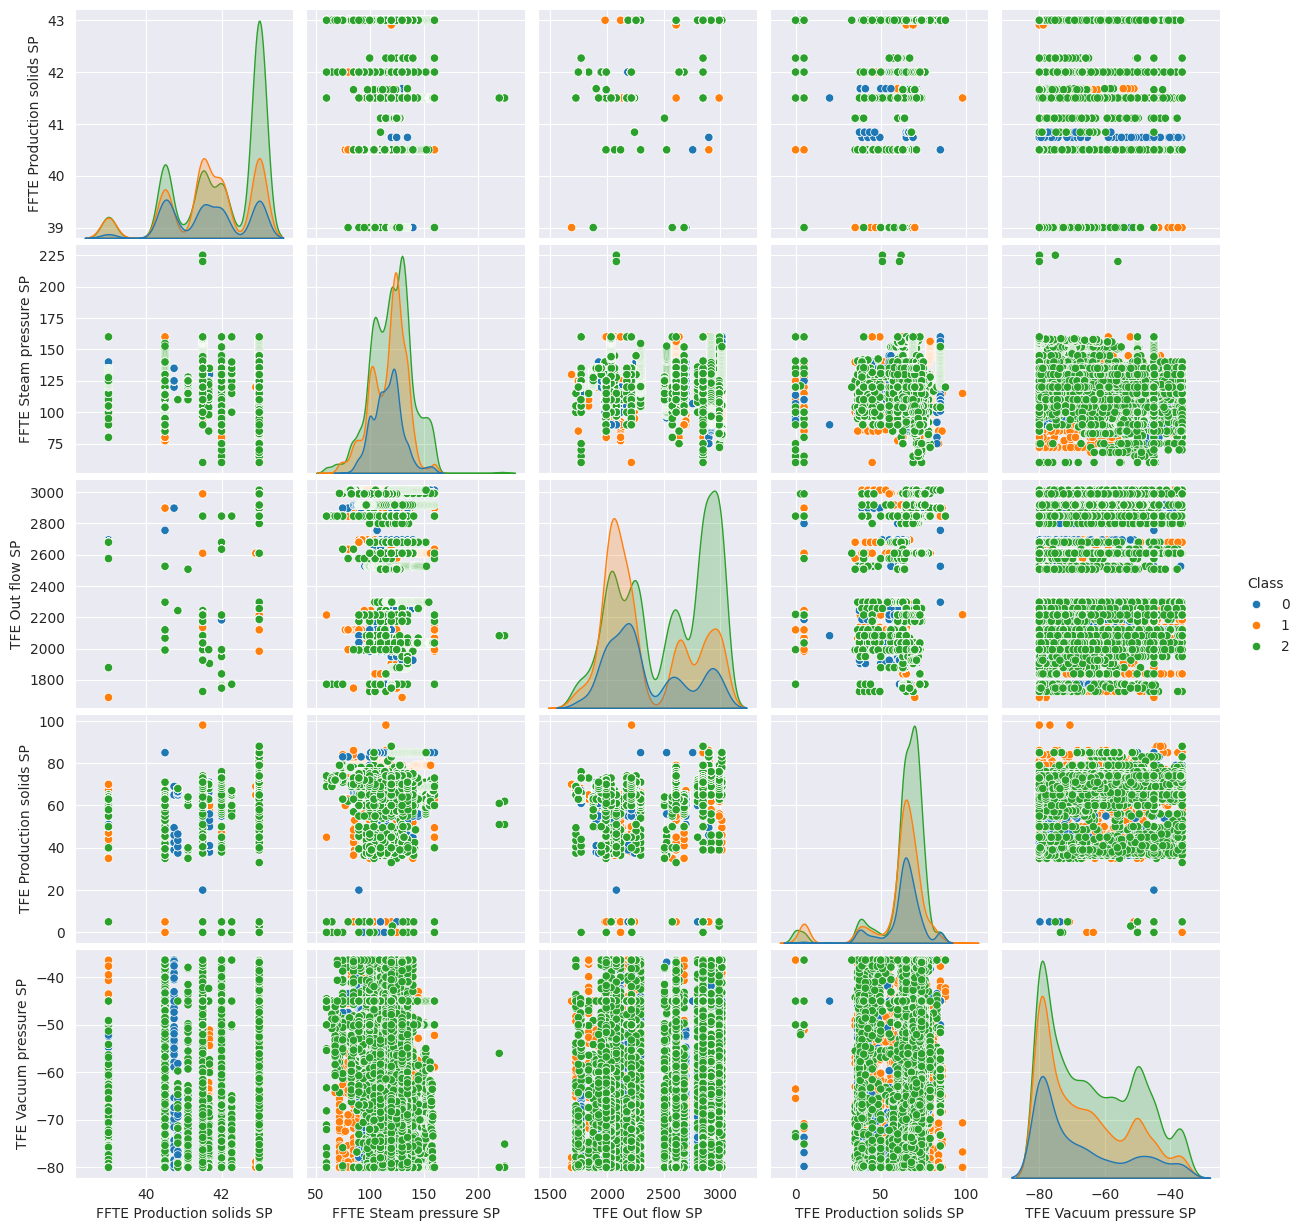

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Show basic stats
print(train_df.describe(include='all'))

# Correlation heatmap (numeric features only)
plt.figure(figsize=(16, 10))
sns.heatmap(train_df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Visualize class distribution
sns.countplot(data=df, x='Class')
plt.title("Class Distribution")
plt.show()

# Pairplot of selected numeric features
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns[:5]  # pick top 5 for clarity
sns.pairplot(df[numeric_cols.tolist() + ['Class']], hue='Class')
plt.show()


In [11]:
X_train = train_df.drop(columns=['Class'])
y_train = train_df['Class']
X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

Selected features: ['FFTE Production solids SP', 'TFE Out flow SP', 'TFE Vacuum pressure SP', 'FFTE Feed flow SP', 'FFTE Out steam temp SP', 'FFTE Feed flow rate PV', 'FFTE Heat temperature 1', 'FFTE Temperature 1 - 1', 'FFTE Temperature 1 - 2', 'FFTE Temperature 2 - 1', 'FFTE Temperature 3 - 2', 'FFTE Unk Temperature', 'TFE Steam temperature', 'TFE Temperature', 'TFE Vacuum pressure PV']

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       333
           1       1.00      0.82      0.90       333
           2       0.90      1.00      0.95       333

    accuracy                           0.94       999
   macro avg       0.94      0.94      0.94       999
weighted avg       0.94      0.94      0.94       999



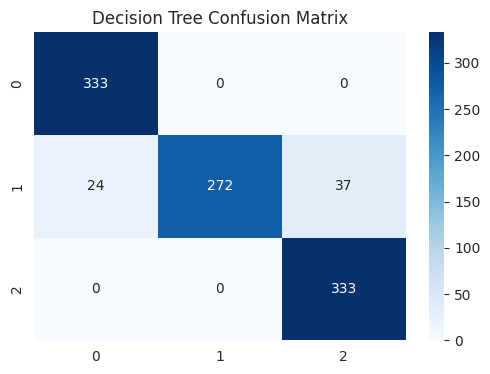


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       333
           1       1.00      0.82      0.90       333
           2       0.87      1.00      0.93       333

    accuracy                           0.94       999
   macro avg       0.95      0.94      0.94       999
weighted avg       0.95      0.94      0.94       999



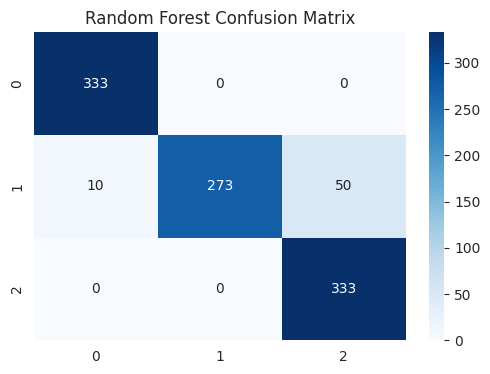


=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       333
           1       0.85      0.68      0.75       333
           2       0.70      0.96      0.81       333

    accuracy                           0.81       999
   macro avg       0.83      0.81      0.80       999
weighted avg       0.83      0.81      0.80       999



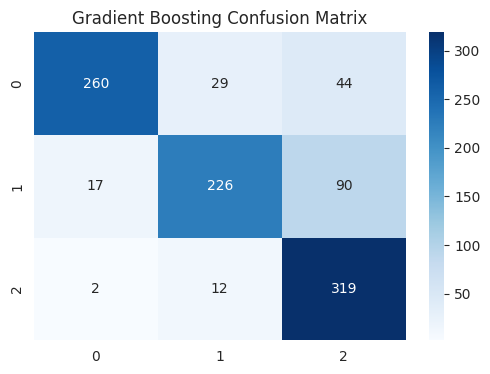


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       333
           1       0.38      0.28      0.32       333
           2       0.40      0.91      0.56       333

    accuracy                           0.40       999
   macro avg       0.59      0.40      0.30       999
weighted avg       0.59      0.40      0.30       999



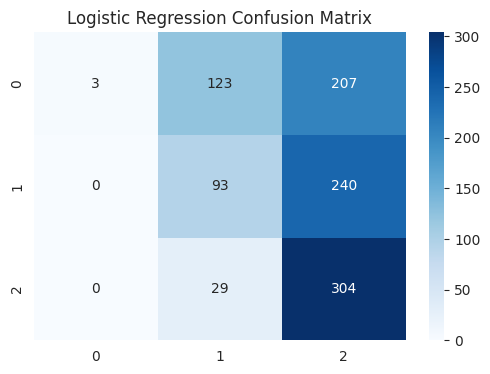


=== SVM ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       333
           1       0.00      0.00      0.00       333
           2       0.33      1.00      0.50       333

    accuracy                           0.33       999
   macro avg       0.11      0.33      0.17       999
weighted avg       0.11      0.33      0.17       999



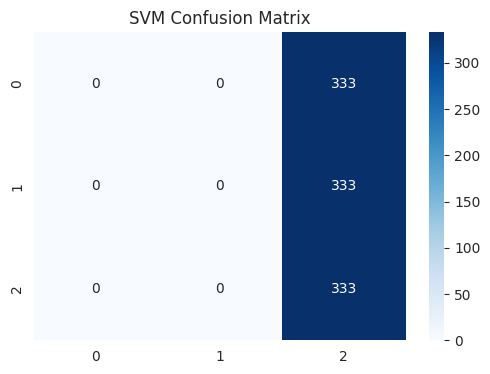


Model Comparison:
                     Precision    Recall  F1-score
Random Forest         0.946766  0.939940  0.938788
Decision Tree         0.944258  0.938939  0.937253
Gradient Boosting     0.827512  0.805806  0.804904
Logistic Regression   0.594795  0.400400  0.300181
SVM                   0.111111  0.333333  0.166667


In [12]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Select top 15 features using ANOVA F-test
selector = SelectKBest(f_classif, k=15)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Store selected feature names for later use
selected_features = X_train.columns[selector.get_support()]
print("Selected features:", selected_features.tolist())

# Define five different models, including Decision Tree
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_selected, y_train)
    preds = model.predict(X_test_selected)
    results[name] = {
        'model': model,
        'report': classification_report(y_test, preds, output_dict=True),
        'confusion_matrix': confusion_matrix(y_test, preds)
    }
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds))
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

# Create and display a comparison table of evaluation metrics
comparison = pd.DataFrame({
    model: {
        'Precision': results[model]['report']['weighted avg']['precision'],
        'Recall': results[model]['report']['weighted avg']['recall'],
        'F1-score': results[model]['report']['weighted avg']['f1-score']
    }
    for model in results
}).T

print("\nModel Comparison:")
print(comparison.sort_values(by='F1-score', ascending=False))


In [ ]:
import joblib

# Random Forest is best based on F1
best_model = results['Random Forest']['model']
joblib.dump(best_model, 'best_model.pkl')

Best model saved as best_model.pkl

--- Best Model Evaluation on Unseen Data ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       333
           1       1.00      0.82      0.90       333
           2       0.87      1.00      0.93       333

    accuracy                           0.94       999
   macro avg       0.95      0.94      0.94       999
weighted avg       0.95      0.94      0.94       999



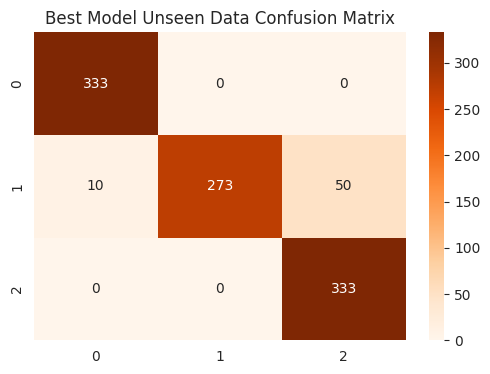


--- Evaluation of All Models on Unseen Data ---

=== Decision Tree on Unseen Data ===
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       333
           1       1.00      0.82      0.90       333
           2       0.90      1.00      0.95       333

    accuracy                           0.94       999
   macro avg       0.94      0.94      0.94       999
weighted avg       0.94      0.94      0.94       999



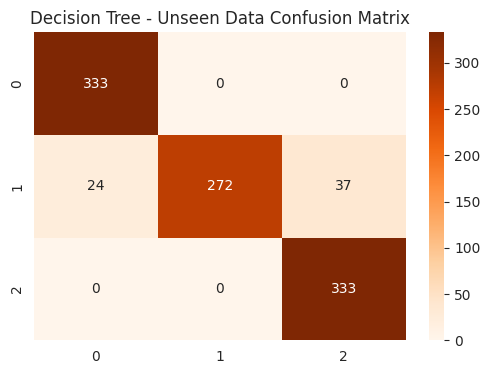


=== Random Forest on Unseen Data ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       333
           1       1.00      0.82      0.90       333
           2       0.87      1.00      0.93       333

    accuracy                           0.94       999
   macro avg       0.95      0.94      0.94       999
weighted avg       0.95      0.94      0.94       999



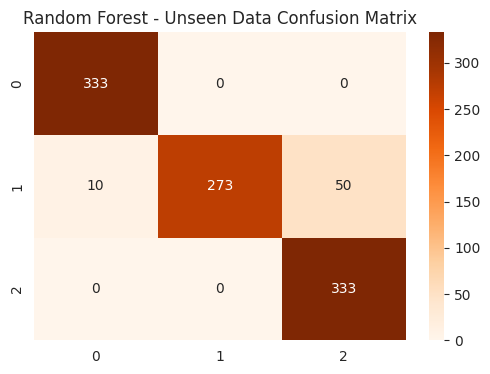


=== Gradient Boosting on Unseen Data ===
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       333
           1       0.85      0.68      0.75       333
           2       0.70      0.96      0.81       333

    accuracy                           0.81       999
   macro avg       0.83      0.81      0.80       999
weighted avg       0.83      0.81      0.80       999



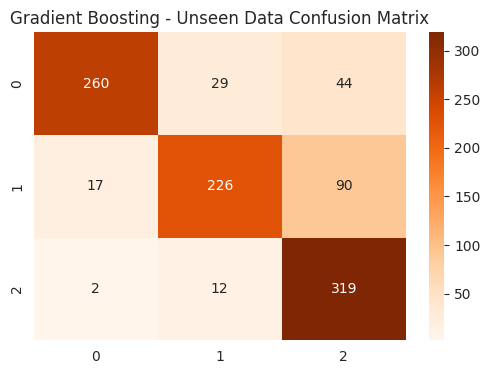


=== Logistic Regression on Unseen Data ===
              precision    recall  f1-score   support

           0       1.00      0.01      0.02       333
           1       0.38      0.28      0.32       333
           2       0.40      0.91      0.56       333

    accuracy                           0.40       999
   macro avg       0.59      0.40      0.30       999
weighted avg       0.59      0.40      0.30       999



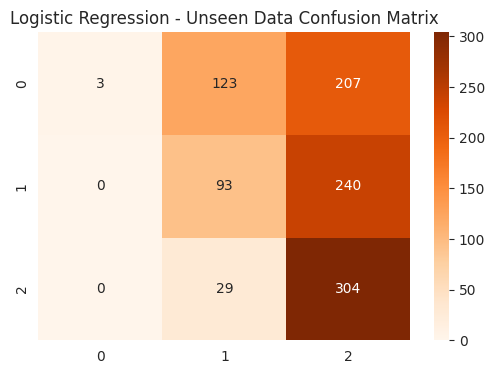


=== SVM on Unseen Data ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       333
           1       0.00      0.00      0.00       333
           2       0.33      1.00      0.50       333

    accuracy                           0.33       999
   macro avg       0.11      0.33      0.17       999
weighted avg       0.11      0.33      0.17       999



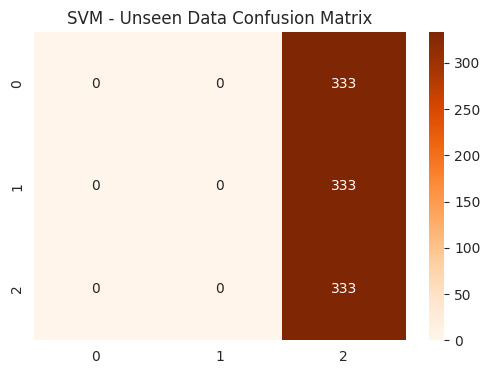


Model ranking on unseen data:
                     F1-score (unseen)
Random Forest                 0.938788
Decision Tree                 0.937253
Gradient Boosting             0.804904
Logistic Regression           0.300181
SVM                           0.166667


In [13]:
import joblib

# Save the best model (here, assuming Random Forest is best based on F1-score)
best_model = results['Random Forest']['model']
joblib.dump(best_model, 'best_model.pkl')
print("Best model saved as best_model.pkl")

# Define unseen data using the selected features from X_test
X_unseen = X_test[selected_features]

# Load the saved best model and evaluate it on unseen data
loaded_model = joblib.load('best_model.pkl')
y_pred_unseen = loaded_model.predict(X_unseen)
print("\n--- Best Model Evaluation on Unseen Data ---")
print(classification_report(y_test, y_pred_unseen))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_unseen), annot=True, fmt='d', cmap='Oranges')
plt.title("Best Model Unseen Data Confusion Matrix")
plt.show()

# Evaluate all models on unseen data
print("\n--- Evaluation of All Models on Unseen Data ---")
model_ranks = {}
for name, model_info in results.items():
    preds_unseen = model_info['model'].predict(X_unseen)
    report = classification_report(y_test, preds_unseen, output_dict=True, zero_division=0)
    f1 = report['weighted avg']['f1-score']
    model_ranks[name] = f1
    print(f"\n=== {name} on Unseen Data ===")
    print(classification_report(y_test, preds_unseen))
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, preds_unseen), annot=True, fmt='d', cmap='Oranges')
    plt.title(f"{name} - Unseen Data Confusion Matrix")
    plt.show()

ranking_df = pd.DataFrame.from_dict(model_ranks, orient='index', columns=['F1-score (unseen)'])
print("\nModel ranking on unseen data:")
print(ranking_df.sort_values(by='F1-score (unseen)', ascending=False))


In [67]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Extract columns ending with 'SP' and include the target variable
sp_cols_only = [col for col in df.columns if col.endswith('SP')]
sp_df = df[sp_cols_only + ['Class']].copy()

# Split sp_df into training and testing sets based on the indices from earlier
test_sp = sp_df.loc[test_df.index]
train_sp = sp_df.drop(test_df.index)

X_sp = train_sp.drop(columns=['Class'])
y_sp = train_sp['Class']

# Train a decision tree model only on SP features
tree_sp = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_sp.fit(X_sp, y_sp)

# Export and print the decision tree rules
tree_rules = export_text(tree_sp, feature_names=list(X_sp.columns))
print("\n--- Decision Tree Rules based on SP Features ---")
print(tree_rules)



--- Decision Tree Rules based on SP Features ---
|--- TFE Out flow SP <= 2241.21
|   |--- FFTE Out steam temp SP <= 49.94
|   |   |--- FFTE Out steam temp SP <= 44.99
|   |   |   |--- class: 0
|   |   |--- FFTE Out steam temp SP >  44.99
|   |   |   |--- class: 2
|   |--- FFTE Out steam temp SP >  49.94
|   |   |--- FFTE Feed flow SP <= 9925.00
|   |   |   |--- FFTE Steam pressure SP <= 119.98
|   |   |   |   |--- class: 2
|   |   |   |--- FFTE Steam pressure SP >  119.98
|   |   |   |   |--- class: 1
|   |   |--- FFTE Feed flow SP >  9925.00
|   |   |   |--- TFE Out flow SP <= 2203.30
|   |   |   |   |--- class: 2
|   |   |   |--- TFE Out flow SP >  2203.30
|   |   |   |   |--- class: 2
|--- TFE Out flow SP >  2241.21
|   |--- FFTE Out steam temp SP <= 50.23
|   |   |--- FFTE Production solids SP <= 40.98
|   |   |   |--- TFE Out flow SP <= 2687.06
|   |   |   |   |--- class: 2
|   |   |   |--- TFE Out flow SP >  2687.06
|   |   |   |   |--- class: 0
|   |   |--- FFTE Production soli